# CICIDS 2017 + 2018 Combined Preprocessing
Output: combined cleaned CSV

In [45]:
import os
import pandas as pd
import numpy as np
from scipy.stats import kruskal
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

DATA_DIR_2017 = r'../dataset/MachineLearningCVE'   # folder containing 2017 daily CSVs
DATA_DIR_2018 = r'../dataset/IDS2018'   # folder containing 2018 daily CSVs
OUTPUT_CSV    = r'combined.csv'   # output path e.g. cicids_combined.csv
FEATURE_LIST_TXT = r'features.txt'  # output path e.g. final_features.txt

## 1. Column rename map (2018 abbreviated -> 2017 names)

In [46]:
RENAME_2018 = {
    'Dst Port':            'Destination Port',
    'Tot Fwd Pkts':        'Total Fwd Packets',
    'Tot Bwd Pkts':        'Total Backward Packets',
    'TotLen Fwd Pkts':     'Total Length of Fwd Packets',
    'TotLen Bwd Pkts':     'Total Length of Bwd Packets',
    'Fwd Pkt Len Max':     'Fwd Packet Length Max',
    'Fwd Pkt Len Min':     'Fwd Packet Length Min',
    'Fwd Pkt Len Mean':    'Fwd Packet Length Mean',
    'Fwd Pkt Len Std':     'Fwd Packet Length Std',
    'Bwd Pkt Len Max':     'Bwd Packet Length Max',
    'Bwd Pkt Len Min':     'Bwd Packet Length Min',
    'Bwd Pkt Len Mean':    'Bwd Packet Length Mean',
    'Bwd Pkt Len Std':     'Bwd Packet Length Std',
    'Flow Byts/s':         'Flow Bytes/s',
    'Flow Pkts/s':         'Flow Packets/s',
    'Fwd IAT Tot':         'Fwd IAT Total',
    'Bwd IAT Tot':         'Bwd IAT Total',
    'Fwd Header Len':      'Fwd Header Length',
    'Bwd Header Len':      'Bwd Header Length',
    'Fwd Pkts/s':          'Fwd Packets/s',
    'Bwd Pkts/s':          'Bwd Packets/s',
    'Pkt Len Min':         'Min Packet Length',
    'Pkt Len Max':         'Max Packet Length',
    'Pkt Len Mean':        'Packet Length Mean',
    'Pkt Len Std':         'Packet Length Std',
    'Pkt Len Var':         'Packet Length Variance',
    'FIN Flag Cnt':        'FIN Flag Count',
    'SYN Flag Cnt':        'SYN Flag Count',
    'RST Flag Cnt':        'RST Flag Count',
    'PSH Flag Cnt':        'PSH Flag Count',
    'ACK Flag Cnt':        'ACK Flag Count',
    'URG Flag Cnt':        'URG Flag Count',
    'ECE Flag Cnt':        'ECE Flag Count',
    'Pkt Size Avg':        'Average Packet Size',
    'Fwd Seg Size Avg':    'Avg Fwd Segment Size',
    'Bwd Seg Size Avg':    'Avg Bwd Segment Size',
    'Fwd Byts/b Avg':      'Fwd Avg Bytes/Bulk',
    'Fwd Pkts/b Avg':      'Fwd Avg Packets/Bulk',
    'Fwd Blk Rate Avg':    'Fwd Avg Bulk Rate',
    'Bwd Byts/b Avg':      'Bwd Avg Bytes/Bulk',
    'Bwd Pkts/b Avg':      'Bwd Avg Packets/Bulk',
    'Bwd Blk Rate Avg':    'Bwd Avg Bulk Rate',
    'Subflow Fwd Pkts':    'Subflow Fwd Packets',
    'Subflow Fwd Byts':    'Subflow Fwd Bytes',
    'Subflow Bwd Pkts':    'Subflow Bwd Packets',
    'Subflow Bwd Byts':    'Subflow Bwd Bytes',
    'Init Fwd Win Byts':   'Init_Win_bytes_forward',
    'Init Bwd Win Byts':   'Init_Win_bytes_backward',
    'Fwd Act Data Pkts':   'act_data_pkt_fwd',
    'Fwd Seg Size Min':    'min_seg_size_forward',
}

## 2. Label maps

In [47]:
LABEL_MAP_2017 = {
    'BENIGN':           'Normal Traffic',
    'DoS Hulk':         'DoS',
    'DoS GoldenEye':    'DoS',
    'DoS slowloris':    'DoS',
    'DoS Slowhttptest': 'DoS',
    'DDoS':             'DDoS',
    'FTP-Patator':      'Brute Force',
    'SSH-Patator':      'Brute Force',
    'PortScan':         'Port Scan',
    # drop
    'Bot': None,
    'Web Attack \ufffd Brute Force': None,
    'Web Attack \ufffd XSS': None,
    'Web Attack \ufffd Sql Injection': None,
    'Infiltration': None,
    'Heartbleed': None,
}

# 2018 labels are case-insensitive matched; anything not listed is dropped
LABEL_MAP_2018 = {
    'benign':                    'Normal Traffic',
    'ftp-bruteforce':            'Brute Force',
    'ssh-bruteforce':            'Brute Force',
    'dos attacks-goldeneye':     'DoS',
    'dos attacks-slowloris':     'DoS',
    'dos attacks-hulk':          'DoS',
    'dos attacks-slowhttptest':  'DoS',
    'ddos attacks-loic-http':    'DDoS',
    'ddos attack-loic-udp':      'DDoS',
    'ddos attack-hoic':          'DDoS',
    # drop: Bot, Infiltration, Brute Force-Web, Brute Force-XSS, SQL Injection
}

## 3. Load 2017

In [48]:
dfs = []
for f in sorted(os.listdir(DATA_DIR_2017)):
    if not f.endswith('.csv'):
        continue
    tmp = pd.read_csv(os.path.join(DATA_DIR_2017, f), low_memory=False)
    tmp.columns = tmp.columns.str.strip()
    dfs.append(tmp)
    print(f'{f}: {tmp.shape}')

df17 = pd.concat(dfs, ignore_index=True)
print(f'\n2017 combined: {df17.shape}')

label_col = ' Label' if ' Label' in df17.columns else 'Label'
df17[label_col] = df17[label_col].str.strip()
unmapped = set(df17[label_col].unique()) - set(LABEL_MAP_2017.keys())
if unmapped:
    print(f'WARNING unmapped 2017 labels: {unmapped}')
df17['Attack Type'] = df17[label_col].map(LABEL_MAP_2017)
df17 = df17[df17['Attack Type'].notna()].reset_index(drop=True)
df17 = df17.drop(columns=[label_col])
df17['Source'] = '2017'
print(df17['Attack Type'].value_counts())

Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: (225745, 79)
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: (286467, 79)
Friday-WorkingHours-Morning.pcap_ISCX.csv: (191033, 79)
Monday-WorkingHours.pcap_ISCX.csv: (529918, 79)
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: (288602, 79)
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: (170366, 79)
Tuesday-WorkingHours.pcap_ISCX.csv: (445909, 79)
Wednesday-workingHours.pcap_ISCX.csv: (692703, 79)

2017 combined: (2830743, 79)
Attack Type
Normal Traffic    2273097
DoS                252661
Port Scan          158930
DDoS               128027
Brute Force         13835
Name: count, dtype: int64


## 4. Load 2018

In [49]:
dfs = []
for f in sorted(os.listdir(DATA_DIR_2018)):
    if not f.endswith('.csv'):
        continue
    tmp = pd.read_csv(os.path.join(DATA_DIR_2018, f), low_memory=False)
    tmp.columns = tmp.columns.str.strip()
    tmp = tmp.rename(columns=RENAME_2018)
    # 2018 files contain repeated header rows inside the data
    tmp = tmp[tmp['Label'].astype(str).str.strip() != 'Label'].copy()
    dfs.append(tmp)
    print(f'{f}: {tmp.shape}')

df18 = pd.concat(dfs, ignore_index=True)
for col in df18.columns:
    if col not in ('Attack Type', 'Source', 'Label'):
        df18[col] = pd.to_numeric(df18[col], errors='coerce')
print(f'\n2018 combined: {df18.shape}')

df18['Label'] = df18['Label'].astype(str).str.strip()
unmapped = set(df18['Label'].str.lower().unique()) - set(LABEL_MAP_2018.keys())
if unmapped:
    print(f'Dropping unmapped 2018 labels: {unmapped}')
df18['Attack Type'] = df18['Label'].str.lower().map(LABEL_MAP_2018)
df18 = df18[df18['Attack Type'].notna()].reset_index(drop=True)
df18 = df18.drop(columns=['Label', 'Protocol', 'Timestamp'], errors='ignore')
df18['Source'] = '2018'
print(df18['Attack Type'].value_counts())

BruteForce.csv: (1048575, 80)
BruteForce2.csv: (1048575, 80)
BruteForceSSH.csv: (1048575, 80)
DDoS.csv: (1048575, 80)
DoS.csv: (1048575, 80)
DoS2.csv: (1048574, 80)

2018 combined: (6291449, 80)
Dropping unmapped 2018 labels: {'brute force -web', 'brute force -xss', 'sql injection'}
Attack Type
Normal Traffic    4567530
DDoS               687742
DoS                654300
Brute Force        380949
Name: count, dtype: int64


## 5. Align columns and combine

In [50]:
numeric_cols_17 = df17.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_18 = df18.select_dtypes(include=[np.number]).columns.tolist()

# Common numeric columns
common_numeric = [c for c in numeric_cols_17 if c in numeric_cols_18]
only_17 = [c for c in numeric_cols_17 if c not in numeric_cols_18]
only_18 = [c for c in numeric_cols_18 if c not in numeric_cols_17]
print(f'Common numeric: {len(common_numeric)}')
print(f'Only in 2017:   {only_17}')
print(f'Only in 2018:   {only_18}')

df = pd.concat(
    [df17[common_numeric + ['Attack Type', 'Source']],
     df18[common_numeric + ['Attack Type', 'Source']]],
    ignore_index=True
)
print(df17.dtypes.value_counts())
print(df18.dtypes.value_counts())
print(f'common_numeric count: {len(common_numeric)}')
print(f'\nCombined: {df.shape}')
print(df['Attack Type'].value_counts())
print(df['Source'].value_counts())

Common numeric: 77
Only in 2017:   ['Fwd Header Length.1']
Only in 2018:   []
int64      54
float64    24
str         2
Name: count, dtype: int64
int64      53
float64    24
str         2
Name: count, dtype: int64
common_numeric count: 77

Combined: (9117071, 79)
Attack Type
Normal Traffic    6840627
DoS                906961
DDoS               815769
Brute Force        394784
Port Scan          158930
Name: count, dtype: int64
Source
2018    6290521
2017    2826550
Name: count, dtype: int64


## 6. Drop constant columns

In [51]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
constant_cols = [c for c in numeric_cols if df[c].nunique() <= 1]
print(f'Dropping constant columns: {constant_cols}')
df = df.drop(columns=constant_cols)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

Dropping constant columns: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


## 7. Handle Inf / NaN

In [52]:
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
before = len(df)
df = df.dropna(subset=numeric_cols).reset_index(drop=True)
print(f'Dropped {before - len(df):,} rows with NaN/inf. Remaining: {len(df):,}')

Dropped 26,026 rows with NaN/inf. Remaining: 9,091,045


## 8. Drop duplicate rows

In [53]:
before = len(df)
df = df.drop_duplicates(subset=numeric_cols).reset_index(drop=True)
print(f'Dropped {before - len(df):,} duplicates. Remaining: {len(df):,}')
print(df['Attack Type'].value_counts())

Dropped 2,263,887 duplicates. Remaining: 6,827,158
Attack Type
Normal Traffic    5914415
DoS                390200
DDoS               328605
Brute Force        103244
Port Scan           90694
Name: count, dtype: int64


In [54]:
normal_mask = df['Attack Type'] == 'Normal Traffic'
normal_rows = df[normal_mask]
attack_rows = df[~normal_mask]

normal_sampled = normal_rows.sample(frac=0.15, random_state=42)
df = pd.concat([attack_rows, normal_sampled], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print(df['Attack Type'].value_counts())

Attack Type
Normal Traffic    887162
DoS               390200
DDoS              328605
Brute Force       103244
Port Scan          90694
Name: count, dtype: int64


## 9. Drop correlated features

In [55]:
corr_drop = [
    'Fwd IAT Total', 'Subflow Fwd Packets', 'Subflow Bwd Packets',
    'Subflow Fwd Bytes', 'Subflow Bwd Bytes', 'Avg Fwd Segment Size',
    'Avg Bwd Segment Size', 'Fwd PSH Flags', 'Fwd URG Flags',
    'Fwd Header Length.1', 'ECE Flag Count', 'Average Packet Size',
    'Fwd IAT Max', 'Fwd Packets/s', 'Idle Max', 'Idle Min', 'Down/Up Ratio',
]
existing = [c for c in corr_drop if c in df.columns]
df = df.drop(columns=existing)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Remaining after corr drop: {len(numeric_cols)}')

Remaining after corr drop: 53


## 10. Kruskal-Wallis — drop statistically irrelevant features

In [56]:
sample = df.sample(min(50000, len(df)), random_state=42)
kw_results = {}
for col in numeric_cols:
    col_groups = [sample[sample['Attack Type'] == c][col].values
                  for c in sample['Attack Type'].unique()]
    try:
        _, p = kruskal(*col_groups)
        kw_results[col] = p
    except:
        kw_results[col] = 1.0

kw_series = pd.Series(kw_results).sort_values(ascending=False)
kw_drop = kw_series[kw_series > 0.05].index.tolist()
print(f'Kruskal-Wallis drop (p > 0.05): {kw_drop}')
if kw_drop:
    df = df.drop(columns=kw_drop)
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Remaining after KW: {len(numeric_cols)}')

Kruskal-Wallis drop (p > 0.05): ['CWE Flag Count']
Remaining after KW: 52


## 11. Random Forest feature importance

In [57]:
sample = df.sample(min(50000, len(df)), random_state=42)
le = LabelEncoder()
y_sample = le.fit_transform(sample['Attack Type'])
X_sample = sample[numeric_cols]

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_sample, y_sample)

importances = pd.Series(rf.feature_importances_, index=numeric_cols).sort_values(ascending=False)
print(importances)

threshold = importances.quantile(0.10)
rf_drop = importances[importances < threshold].index.tolist()
print(f'\nRF drop (bottom 10%): {rf_drop}')
if rf_drop:
    df = df.drop(columns=rf_drop)
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Final feature count: {len(numeric_cols)}')
print(numeric_cols)

Destination Port               0.101471
min_seg_size_forward           0.068762
Init_Win_bytes_forward         0.067078
Fwd Header Length              0.050860
Bwd Packet Length Mean         0.035635
Bwd Packet Length Std          0.034362
Packet Length Std              0.034246
Bwd Header Length              0.034078
Bwd Packets/s                  0.031855
Max Packet Length              0.031839
Total Length of Fwd Packets    0.028952
Total Fwd Packets              0.027645
act_data_pkt_fwd               0.027180
Total Length of Bwd Packets    0.026903
Fwd IAT Mean                   0.024947
Packet Length Variance         0.024047
Fwd IAT Min                    0.023921
Fwd Packet Length Mean         0.023416
Init_Win_bytes_backward        0.023246
Total Backward Packets         0.021866
Fwd Packet Length Max          0.020411
Packet Length Mean             0.019088
Bwd Packet Length Max          0.018492
Bwd Packet Length Min          0.017185
Flow IAT Max                   0.015594


## 12. Save output

In [58]:
final_cols = numeric_cols + ['Attack Type', 'Source']
df = df[final_cols]

print(f'Final shape: {df.shape}')
print('\nClass distribution:')
print(df['Attack Type'].value_counts())
print('\nSource distribution:')
print(df['Source'].value_counts())

df.to_csv(OUTPUT_CSV, index=False)
print(f'\nSaved: {OUTPUT_CSV}')

with open(FEATURE_LIST_TXT, 'w') as f:
    for col in numeric_cols:
        f.write(col + '\n')
print(f'Saved feature list: {FEATURE_LIST_TXT}')
print('\nFinal features:')
for i, col in enumerate(numeric_cols):
    print(f'  {i+1:2d}. {col}')

Final shape: (1799905, 48)

Class distribution:
Attack Type
Normal Traffic    887162
DoS               390200
DDoS              328605
Brute Force       103244
Port Scan          90694
Name: count, dtype: int64

Source distribution:
Source
2018    1064113
2017     735792
Name: count, dtype: int64

Saved: combined.csv
Saved feature list: features.txt

Final features:
   1. Destination Port
   2. Flow Duration
   3. Total Fwd Packets
   4. Total Backward Packets
   5. Total Length of Fwd Packets
   6. Total Length of Bwd Packets
   7. Fwd Packet Length Max
   8. Fwd Packet Length Min
   9. Fwd Packet Length Mean
  10. Fwd Packet Length Std
  11. Bwd Packet Length Max
  12. Bwd Packet Length Min
  13. Bwd Packet Length Mean
  14. Bwd Packet Length Std
  15. Flow Bytes/s
  16. Flow Packets/s
  17. Flow IAT Mean
  18. Flow IAT Std
  19. Flow IAT Max
  20. Flow IAT Min
  21. Fwd IAT Mean
  22. Fwd IAT Std
  23. Fwd IAT Min
  24. Bwd IAT Total
  25. Bwd IAT Mean
  26. Bwd IAT Std
  27. Bwd IA

## 13. Class distribution visualization

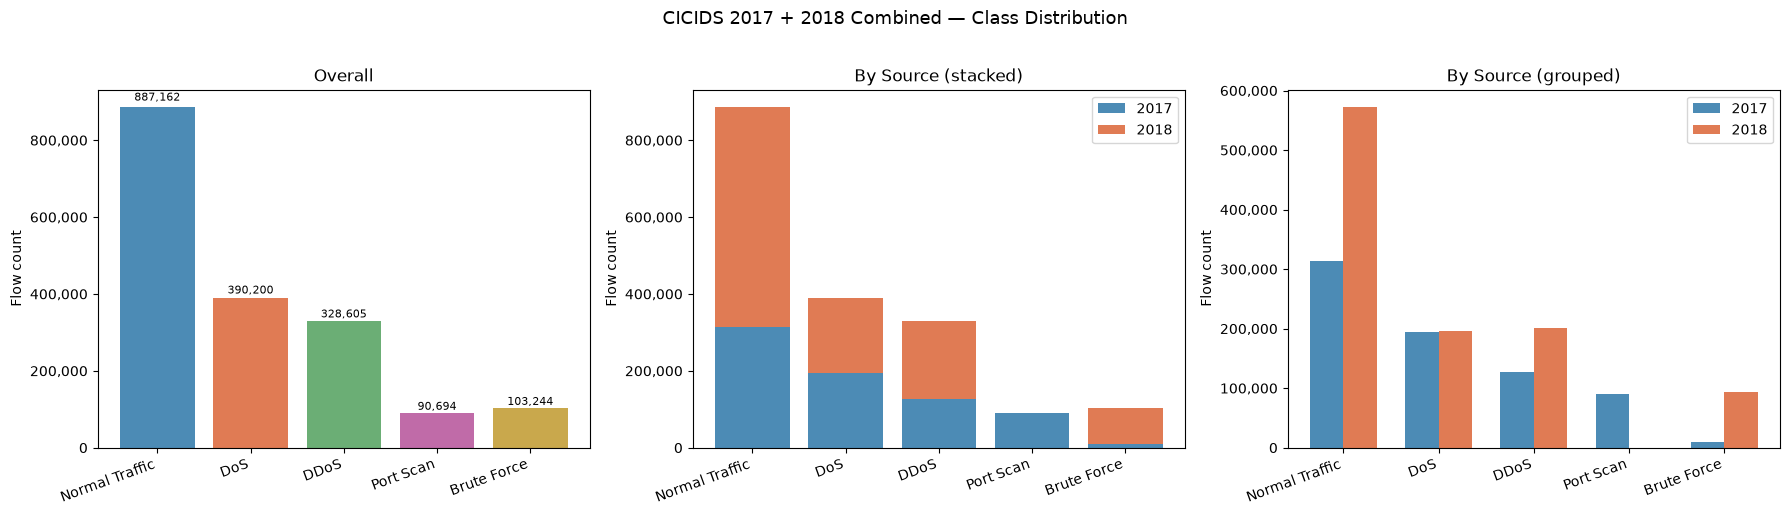

Saved: combined_class_distribution.png


In [59]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

CLASSES = ['Normal Traffic', 'DoS', 'DDoS', 'Port Scan', 'Brute Force']
colors  = ['#4C8BB5', '#E07B54', '#6BAE75', '#C06BA8', '#C9A84C']

# --- overall counts ---
overall = df['Attack Type'].value_counts().reindex(CLASSES, fill_value=0)

# --- per-source counts ---
by_src = (
    df.groupby(['Source', 'Attack Type'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=CLASSES, fill_value=0)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('CICIDS 2017 + 2018 Combined — Class Distribution', fontsize=13, y=1.02)

# Plot 1: overall bar chart
ax = axes[0]
bars = ax.bar(CLASSES, overall.values, color=colors)
ax.set_title('Overall')
ax.set_ylabel('Flow count')
ax.set_xticklabels(CLASSES, rotation=20, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, overall.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
            f'{val:,}', ha='center', va='bottom', fontsize=8)

# Plot 2: stacked bar by source
ax = axes[1]
bottom = np.zeros(len(CLASSES))
src_colors = {'2017': '#4C8BB5', '2018': '#E07B54'}
for src in by_src.index:
    vals = by_src.loc[src].values
    ax.bar(CLASSES, vals, bottom=bottom, label=src, color=src_colors.get(src, 'grey'))
    bottom += vals
ax.set_title('By Source (stacked)')
ax.set_ylabel('Flow count')
ax.set_xticklabels(CLASSES, rotation=20, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()

# Plot 3: grouped bar by source
ax = axes[2]
x = np.arange(len(CLASSES))
width = 0.35
srcs = list(by_src.index)
for i, src in enumerate(srcs):
    offset = (i - len(srcs) / 2 + 0.5) * width
    vals = by_src.loc[src].values
    ax.bar(x + offset, vals, width, label=src, color=src_colors.get(src, 'grey'))
ax.set_title('By Source (grouped)')
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, rotation=20, ha='right')
ax.set_ylabel('Flow count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()

plt.tight_layout()
plt.savefig('combined_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: combined_class_distribution.png')